# Logistic Growth

Pure exponential growth $\dot{x} = rx$ is unrealistic for populations: it predicts unlimited growth regardless of resources. The **logistic model** corrects this by adding a density-dependent brake — as the population $x$ approaches a **carrying capacity** $K$, the growth rate slows and eventually stops.

The logistic ODE is one of the most important models in ecology, epidemiology, and economics. It is also a perfect example of **fixed-point stability analysis** — we can completely characterize long-term behavior without solving the equation.

## The Logistic ODE

$$\dot{x} = r x\!\left(1 - \frac{x}{K}\right), \qquad x(0) = x_0$$

**Parameters:**
- $r > 0$: intrinsic (per-capita) growth rate at low density.
- $K > 0$: carrying capacity — the equilibrium population.

**Interpretation:** the factor $(1 - x/K)$ is the "fraction of capacity remaining." When $x \ll K$, this factor $\approx 1$ and growth is nearly exponential. When $x = K$, growth stops. When $x > K$, the population declines.

### Exact Solution

By partial fractions and separation of variables:

$$x(t) = \frac{K}{1 + \left(\dfrac{K}{x_0} - 1\right)e^{-rt}}$$

This is a **sigmoid curve** (S-curve): slow initial growth, rapid middle growth, saturation at $K$. The inflection point occurs at $x = K/2$.

## Fixed Points and Stability

A **fixed point** (equilibrium) of $\dot{x} = f(x)$ is a value $x^*$ where $f(x^*) = 0$. Setting $rx^*(1 - x^*/K) = 0$ gives two fixed points:

$$x^* = 0 \quad \text{and} \quad x^* = K$$

**Stability via linearization:** near $x^*$, let $\xi = x - x^*$ be a small perturbation. Then $\dot{\xi} \approx f'(x^*) \cdot \xi$, so the perturbation grows or shrinks exponentially depending on $\text{sign}(f'(x^*))$:

$$f(x) = rx\left(1 - \frac{x}{K}\right) \implies f'(x) = r\left(1 - \frac{2x}{K}\right)$$

| Fixed point | $f'(x^*)$ | Stability |
|:-----------:|:---------:|:---------:|
| $x^* = 0$ | $+r > 0$ | **Unstable** — perturbations grow away |
| $x^* = K$ | $-r < 0$ | **Stable** — perturbations decay back |

Regardless of the initial condition $x_0 > 0$, the solution converges to $K$ as $t \to \infty$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.style.use("dark_background")


# ---- Reusable helpers (same as NB3) ----

def plot_slope_field(f, t_range, x_range, ax, n=20, color='cyan', alpha=0.4):
    t_vals = np.linspace(*t_range, n)
    x_vals = np.linspace(*x_range, n)
    T, X = np.meshgrid(t_vals, x_vals)
    dX = f(T, X)
    dT = np.ones_like(dX)
    length = np.sqrt(dT**2 + dX**2)
    ax.quiver(T, X, dT / length, dX / length,
              alpha=alpha, color=color,
              headlength=0, headaxislength=0,
              pivot='middle', scale=n * 1.5,
              angles='xy')


def euler(f, x0, t0, t_end, h):
    ts = [t0]; xs = [x0]
    t, x = t0, x0
    while t < t_end - 1e-12:
        h_act = min(h, t_end - t)
        x = x + h_act * f(t, x)
        t += h_act
        ts.append(t); xs.append(x)
    return np.array(ts), np.array(xs)

## Slope Field with Fixed Points

The slope field shows arrows pointing upward for $0 < x < K$ (growth) and downward for $x > K$ (decline). The two horizontal dashed lines mark the fixed points: $x^* = 0$ (unstable — arrows point away) and $x^* = K$ (stable — arrows point toward).

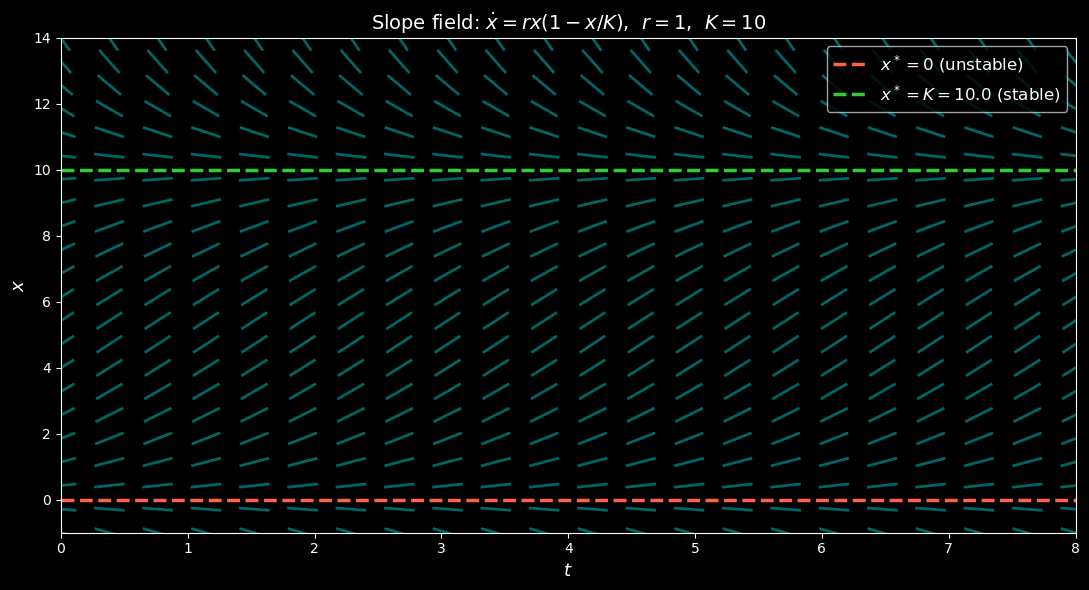

In [2]:
r = 1.0
K = 10.0
f_log = lambda t, x: r * x * (1 - x / K)

fig, ax = plt.subplots(figsize=(11, 6))
plot_slope_field(f_log, (0, 8), (-1, 14), ax, n=22)
ax.axhline(0, color='tomato',     lw=2.5, ls='--', label='$x^* = 0$ (unstable)')
ax.axhline(K, color='limegreen',  lw=2.5, ls='--', label=f'$x^* = K = {K}$ (stable)')
ax.set_xlabel('$t$', fontsize=13)
ax.set_ylabel('$x$', fontsize=13)
ax.set_title(r'Slope field: $\dot{x} = rx(1 - x/K)$,  $r=1$,  $K=10$', fontsize=14)
ax.set_xlim(0, 8); ax.set_ylim(-1, 14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Euler vs scipy vs Exact Solution

For the logistic ODE, the exact solution is known, so we can verify both Euler's method and scipy against it. Notice that Euler with a large step ($h = 0.5$) overshoots visibly, while scipy matches the exact sigmoid almost perfectly.

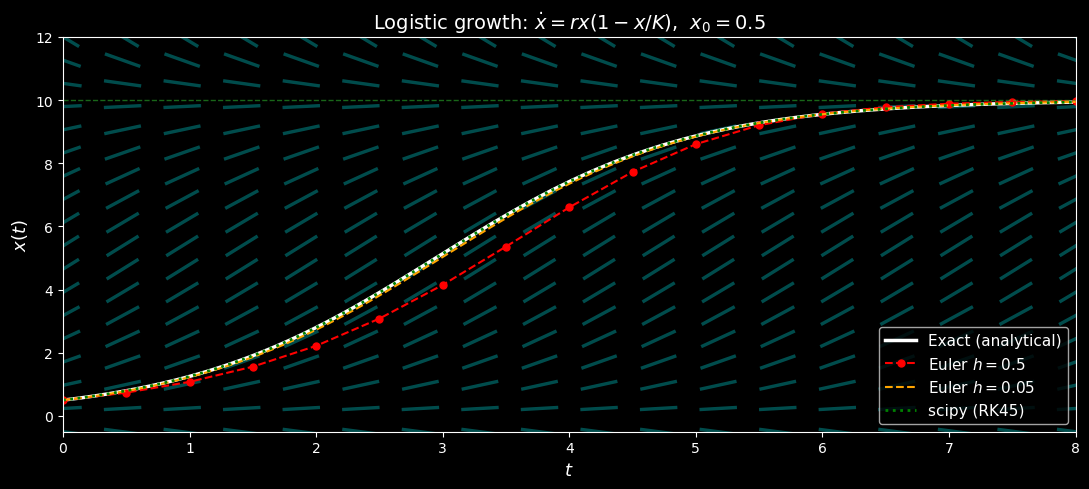

In [3]:
x0 = 0.5
T = 8.0

# Exact solution
t_ex = np.linspace(0, T, 400)
x_exact = K / (1 + (K / x0 - 1) * np.exp(-r * t_ex))

# Euler
t_e1, x_e1 = euler(f_log, x0, 0, T, h=0.5)
t_e2, x_e2 = euler(f_log, x0, 0, T, h=0.05)

# scipy
sol = solve_ivp(f_log, (0, T), [x0], dense_output=True, max_step=0.05)
x_sci = sol.sol(t_ex)[0]

fig, ax = plt.subplots(figsize=(11, 5))
plot_slope_field(f_log, (0, T), (-0.5, 12), ax, n=18, alpha=0.3)
ax.plot(t_ex, x_exact, 'w-',       lw=2.5, label='Exact (analytical)')
ax.plot(t_e1, x_e1,   'r--o',     ms=5,   label='Euler $h = 0.5$')
ax.plot(t_e2, x_e2,   color='orange', ls='--', lw=1.5, label='Euler $h = 0.05$')
ax.plot(t_ex, x_sci,  'g:',       lw=2,   label='scipy (RK45)')
ax.axhline(K, color='limegreen', lw=1, ls='--', alpha=0.5)
ax.set_xlim(0, T); ax.set_ylim(-0.5, 12)
ax.set_xlabel('$t$', fontsize=13); ax.set_ylabel('$x(t)$', fontsize=13)
ax.set_title(r'Logistic growth: $\dot{x}=rx(1-x/K)$,  $x_0=0.5$', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Families of Solution Curves

The logistic equation's behavior depends strongly on the initial condition:

- **$0 < x_0 < K$**: S-shaped curve, asymptotically approaching $K$ from below.
- **$x_0 = K$**: constant solution (already at equilibrium).
- **$x_0 > K$**: monotone decrease toward $K$ from above.
- **$x_0 < 0$**: diverges to $-\infty$ (mathematically, not biologically, valid).

All trajectories with $x_0 > 0$ converge to $K$ — confirming its global stability on $(0, \infty)$.

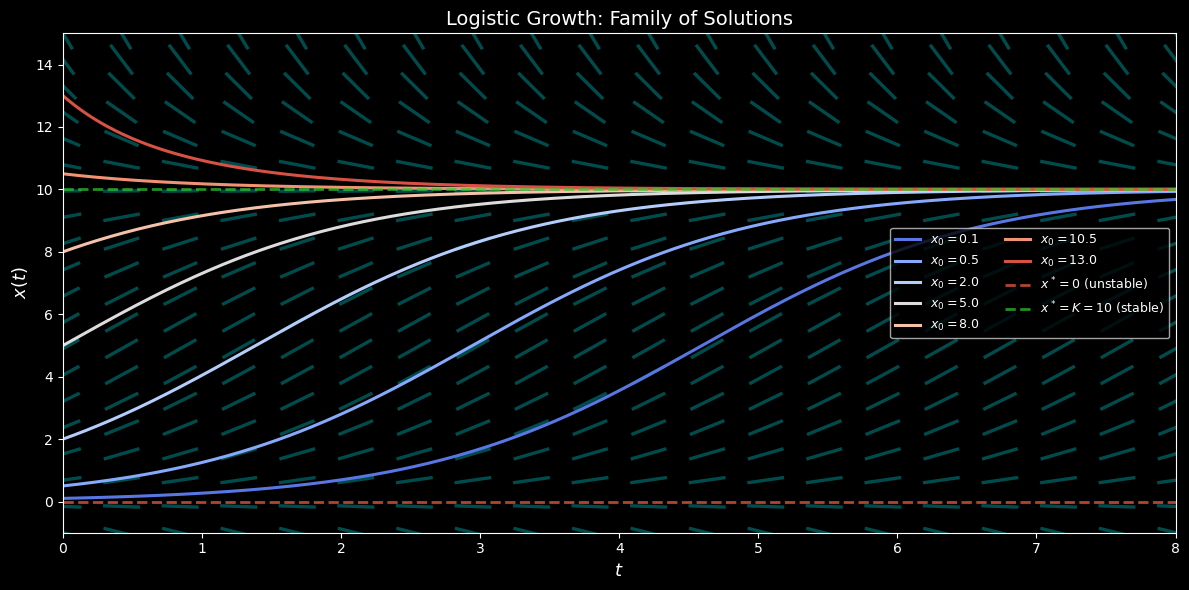

In [4]:
initial_conditions = [0.1, 0.5, 2.0, 5.0, 8.0, 10.5, 13.0]
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(initial_conditions)))

fig, ax = plt.subplots(figsize=(12, 6))
plot_slope_field(f_log, (0, 8), (-1, 15), ax, n=20, alpha=0.3)

for x0_val, col in zip(initial_conditions, colors):
    sol = solve_ivp(f_log, (0, 8), [x0_val], dense_output=True, max_step=0.05)
    t_p = np.linspace(0, 8, 400)
    y_p = sol.sol(t_p)[0]
    ax.plot(t_p, y_p, lw=2.2, color=col, label=f'$x_0 = {x0_val}$')

ax.axhline(0, color='tomato',    lw=2, ls='--', alpha=0.7, label='$x^*=0$ (unstable)')
ax.axhline(K, color='limegreen', lw=2, ls='--', alpha=0.7, label='$x^*=K=10$ (stable)')
ax.set_xlim(0, 8); ax.set_ylim(-1, 15)
ax.set_xlabel('$t$', fontsize=13); ax.set_ylabel('$x(t)$', fontsize=13)
ax.set_title('Logistic Growth: Family of Solutions', fontsize=14)
ax.legend(fontsize=9, ncol=2, loc='center right')
plt.tight_layout()
plt.show()

## Biological Interpretation

The logistic model was first proposed by Pierre François Verhulst (1838) and later independently by Pearl and Reed (1920) to model human population growth. It remains the canonical model for **density-dependent** population dynamics.

**Key ecological concepts captured:**
- **Carrying capacity** $K$: the maximum sustainable population given resource limitations.
- **Maximum growth rate** occurs at $x = K/2$ (the inflection point of the S-curve).
- **Global stability**: the population always returns to $K$ after perturbation, provided it remains positive.

**Limitations:** the logistic model assumes a fixed $K$, instantaneous feedback, and a homogeneous population. Real populations are subject to stochasticity, age structure, spatial effects, and time-varying environments — extensions that lead to much richer models.